<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/RAG_HandsOn_self.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Production-Grade Document Q&A System
### Chunking · Embeddings · Semantic Search · Approximate Nearest Neighbours · End-to-end RAG

This notebook is a single, runnable tour of how real Retrieval-Augmented-Generation (RAG)
systems are built.

We work on a **real,
large-document dataset** (full scientific papers), run **controlled chunking experiments**,
**benchmark every major FAISS index** (Flat, IVF, PQ, IVF+PQ, HNSW), and finally assemble a
**complete Document Q&A pipeline** with answer generation and evaluation.

It runs on a **free Google Colab tier** (CPU works; a T4 GPU just makes embedding faster).

---

#### The pipeline we are building

```
                          ┌──────────────────────────────────────────────────────────┐
   raw files              │                    INGESTION (offline)                    │
  PDF DOCX HTML  ───────► │  load → clean → CHUNK → EMBED → build VECTOR INDEX (FAISS) │
  scans (OCR)             └──────────────────────────────────────────────────────────┘
                                                  │ persisted index + metadata
                                                  ▼
   user question  ─────►  EMBED query ─► ANN SEARCH (top-k) ─► (rerank) ─► LLM with context ─►  grounded answer + citations
                          └────────────────────────  RETRIEVAL + GENERATION (online)  ──────────────────────┘
```

Every box above is its own section below. Each section is self-contained, explained first in
plain language, then implemented cleanly.

#### Roadmap

1. **Setup & configuration** — installs, device, one config object.
2. **Document processing** — PDF, DOCX, HTML and **OCR** basics with a unified loader.
3. **The dataset** — `allenai/qasper`: full papers + questions + gold evidence.
4. **Embeddings** — Sentence-Transformers (local, free) and **OpenAI** (drop-in), behind one interface.
5. **Chunking strategies** — fixed-size, sliding window, semantic.
6. **Chunking experiments** — measure retrieval quality vs. chunk size/strategy and pick a winner.
7. **Exact semantic search** — the correct baseline.
8. **Approximate search deep-dive** — IVF, PQ, each explained and measured.
9. **ANN benchmark** — recall vs. latency vs. memory; when to use which.

> **How to read this notebook.** Run top-to-bottom once. Sections 5–9 reuse a small set of clean
> intermediate objects (`CORPUS`, `EVALSET`, an `Embedder`, and FAISS indexes), so the code stays
> short. Knobs live in the `CFG` object in Section 1 — change them there, not scattered around.

## 0 · Setup & configuration

Two install groups: Python packages (pip) and two system binaries for OCR
(`tesseract` for the OCR engine, `poppler` for rendering PDF pages to images).

> On Colab you can ignore pip's dependency-resolver warnings. If any `import` fails right after
> install, use **Runtime → Restart session** once and re-run — packages are already on disk.

In [1]:
# --- System binaries for the OCR demo (safe to skip if you don't need OCR) ---
!apt-get -qq update  > /dev/null 2>&1
!apt-get -qq install -y tesseract-ocr poppler-utils > /dev/null 2>&1
print("tesseract + poppler installed (for the OCR section).")

tesseract + poppler installed (for the OCR section).


In [2]:
# --- Python packages. Versions pinned to a coherent, current set. ---
%pip install -q \
  "langchain>=0.3,<0.4" "langchain-community>=0.3,<0.4" "langchain-text-splitters>=0.3,<0.4" \
  "langchain-huggingface>=0.1,<0.3" "langchain-openai>=0.2,<0.4" "langchain-experimental>=0.3,<0.4" \
  "sentence-transformers>=3.0" "transformers>=4.45" "accelerate>=0.30" "faiss-cpu>=1.8" "datasets>=2.19,<3.0" \
  "rank-bm25" "tiktoken" "pypdf" "docx2txt" "python-docx" "beautifulsoup4" "lxml" "fpdf2" \
  "pytesseract" "pdf2image" "Pillow" "matplotlib" "pandas"
print("done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.9/382.9 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.0/337.0 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# --- Imports, device detection, reproducibility ---
import os, re, time, json, math, random, warnings, textwrap
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Callable, Optional, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"Device for embeddings: {DEVICE}")
print("If this says 'cpu' and you want speed: Runtime → Change runtime type → T4 GPU.")

Device for embeddings: cuda
If this says 'cpu' and you want speed: Runtime → Change runtime type → T4 GPU.


### One configuration object

Everything tunable lives here. Treat this as the notebook's control panel.

In [4]:
@dataclass
class Config:
    # dataset
    dataset_name: str = "allenai/qasper"
    split: str = "validation"        # ~281 papers; small enough for the free tier
    max_papers: int = 8000             # ↑ for a bigger index (more chunks); ↓ if CPU-bound
    max_eval_questions: int = 15000    # questions used for retrieval evaluation

    # embeddings
    sbert_model: str = "sentence-transformers/all-MiniLM-L6-v2"   # 384-dim, fast, solid
    openai_model: str = "text-embedding-3-small"                  # used only if a key is set
    embed_batch_size: int = 64
    normalize: bool = True           # unit-norm vectors → inner product == cosine

    # default chunking (the experiments in §6 override these)
    chunk_size: int = 600            # characters
    chunk_overlap: int = 120

    # retrieval / search
    top_k: int = 5                   # chunks fed to the LLM
    eval_k: int = 10                 # k used when scoring retrieval

    # generation
    chat_model: str = "gpt-4o-mini"          # OpenAI model, used only if OPENAI_API_KEY is set
    local_llm: str = "Qwen/Qwen2.5-1.5B-Instruct"  # modern open generative LLM for the no-key path
    max_new_tokens: int = 256                # answer length cap for generation
    seed: int = 42

CFG = Config()
print(CFG)

Config(dataset_name='allenai/qasper', split='validation', max_papers=8000, max_eval_questions=15000, sbert_model='sentence-transformers/all-MiniLM-L6-v2', openai_model='text-embedding-3-small', embed_batch_size=64, normalize=True, chunk_size=600, chunk_overlap=120, top_k=5, eval_k=10, chat_model='gpt-4o-mini', local_llm='Qwen/Qwen2.5-1.5B-Instruct', max_new_tokens=256, seed=42)


### (Optional) OpenAI key

The notebook is **fully runnable without any API key** — Sentence-Transformers handles
embeddings locally and a small local model handles answering. If you *do* set a key, the
OpenAI embedding and the LLM-answering cells light up automatically. Nothing else changes.

In [5]:
# Optional: paste a key to enable the OpenAI paths. Leave empty to stay 100% local & free.
# On Colab you can also use the secrets manager (key icon) instead of pasting here.
os.environ.setdefault("OPENAI_API_KEY", "")   # e.g. "sk-..."

try:
    from google.colab import userdata          # pull from Colab Secrets if present
    if not os.environ["OPENAI_API_KEY"]:
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY") or ""
except Exception:
    pass

HAS_OPENAI = bool(os.environ.get("OPENAI_API_KEY"))
print("OpenAI paths:", "ENABLED" if HAS_OPENAI else "disabled (local-only mode — totally fine)")

OpenAI paths: disabled (local-only mode — totally fine)


## 1 · Document processing — PDF · DOCX · HTML · OCR

Raw files must become clean text. In production the corpus is
a messy pile of formats. We cover four types of Corpus meet most often and wrap them in **one dispatcher**,
`load_document(path)`, that returns LangChain `Document` objects (text + metadata) regardless of
the source format.

We first synthesize one small file of each type so the notebook is self-contained, then read them
back with the appropriate loader.

In [6]:
# Make a scratch folder and synthesize one sample file per format.
import os
os.makedirs("/content/samples", exist_ok=True) if os.path.isdir("/content") else os.makedirs("samples", exist_ok=True)
SAMP = "/content/samples" if os.path.isdir("/content") else "samples"

SAMPLE_TEXT = (
    "Retrieval-Augmented Generation (RAG) grounds a language model in an external corpus. "
    "Instead of relying only on parametric memory, the system retrieves relevant passages at "
    "query time and conditions generation on them. This reduces hallucination and lets the "
    "knowledge base be updated without retraining the model."
)

# --- PDF (fpdf2) ---
from fpdf import FPDF
pdf = FPDF(); pdf.add_page(); pdf.set_font("Helvetica", size=12)
pdf.multi_cell(0, 8, "A Short Note on RAG\n\n" + SAMPLE_TEXT)
pdf.output(f"{SAMP}/sample.pdf")

# --- DOCX (python-docx) ---
from docx import Document as Docx
d = Docx(); d.add_heading("A Short Note on RAG", level=1); d.add_paragraph(SAMPLE_TEXT)
d.add_paragraph("Section: Why retrieval helps")
d.add_paragraph("Retrieval keeps answers current and attributable to sources.")
d.save(f"{SAMP}/sample.docx")

# --- HTML ---
html = f"""<!doctype html><html><head><title>RAG note</title></head>
<body><h1>A Short Note on RAG</h1><p>{SAMPLE_TEXT}</p>
<p>Embeddings turn text into vectors so that similar meaning lands nearby.</p></body></html>"""
open(f"{SAMP}/sample.html", "w").write(html)

print("Created:", os.listdir(SAMP))

Created: ['sample.html', 'sample.docx', 'sample.pdf']


### 1.1 · PDF, DOCX, HTML with LangChain loaders

LangChain ships a loader per format. Each returns `Document(page_content=..., metadata=...)`.
The point of using them (rather than hand-parsing) is uniform output and battle-tested edge-case
handling (encrypted PDFs, weird encodings, nested HTML).

In [7]:
from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader, BSHTMLLoader

def short(t, n=160): return (t[:n] + " …") if len(t) > n else t

pdf_docs  = PyPDFLoader(f"{SAMP}/sample.pdf").load()
docx_docs = Docx2txtLoader(f"{SAMP}/sample.docx").load()
html_docs = BSHTMLLoader(f"{SAMP}/sample.html").load()

for label, docs in [("PDF", pdf_docs), ("DOCX", docx_docs), ("HTML", html_docs)]:
    print(f"\n=== {label} === ({len(docs)} document object[s])")
    print("metadata:", docs[0].metadata)
    print("text    :", short(docs[0].page_content.replace(chr(10), " ").strip()))


=== PDF === (1 document object[s])
metadata: {'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '2026-08-15T05:55:42+00:00', 'source': '/content/samples/sample.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}
text    : A Short Note on RAG Retrieval-Augmented Generation (RAG) grounds a language model in an external corpus. Instead of relying only on parametric memory, the syste …

=== DOCX === (1 document object[s])
metadata: {'source': '/content/samples/sample.docx'}
text    : A Short Note on RAG  Retrieval-Augmented Generation (RAG) grounds a language model in an external corpus. Instead of relying only on parametric memory, the syst …

=== HTML === (1 document object[s])
metadata: {'source': '/content/samples/sample.html', 'title': 'RAG note'}
text    : RAG note A Short Note on RAGRetrieval-Augmented Generation (RAG) grounds a language model in an external corpus. Instead of relying only on parametric memory, t …


### 1.2 · OCR basics — reading text from images / scanned PDFs

Many "PDFs" are just photos of pages: there is no text layer, so the loaders above return nothing.
The fix is **Optical Character Recognition**. The standard open-source stack is **Tesseract**
(the OCR engine) driven by **pytesseract**, with **pdf2image/poppler** to rasterize PDF pages into
images first.

The minimal pipeline is: `PDF page → image → tesseract → text`. We demonstrate the core step on a
synthesized image, then show the scanned-PDF wrapper.

In [8]:
# Synthesize an "image of text" (stands in for a scanned page), then OCR it.
from PIL import Image, ImageDraw, ImageFont
import pytesseract

img = Image.new("RGB", (760, 200), "white")
draw = ImageDraw.Draw(img)
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 22)
except Exception:
    font = ImageFont.load_default()
draw.multiline_text((20, 30),
    "Optical Character Recognition turns\npixels of text back into characters.\nTesseract is the workhorse engine.",
    fill="black", font=font, spacing=10)
img.save(f"{SAMP}/scanned.png")

ocr_text = pytesseract.image_to_string(Image.open(f"{SAMP}/scanned.png"))
print("OCR output:\n", ocr_text.strip())

OCR output:
 Optical Character Recognition turns
phelsoltextback intocharacters
Tesseract isthe workhorse engine.


In [9]:
def ocr_pdf(path: str) -> str:
    """OCR a scanned (image-only) PDF: rasterize each page, then run Tesseract.
    Used as a fallback only when a normal PDF loader yields little/no text."""
    from pdf2image import convert_from_path
    pages = convert_from_path(path, dpi=200)
    return "\n\n".join(pytesseract.image_to_string(p) for p in pages)

# (Our sample.pdf has a real text layer, so PyPDFLoader already handles it.
#  ocr_pdf() is what you'd call when len(extracted_text) is suspiciously small.)
print("ocr_pdf() ready — call it when a PDF has no extractable text layer.")

ocr_pdf() ready — call it when a PDF has no extractable text layer.


### 1.3 · A single unified loader

In a real ingestion job you do not want a `for`-loop of `if extension == ...`. Wrap the dispatch
once. This function is the only thing the rest of an ingestion pipeline needs to know about file
formats — and it transparently falls back to OCR when a PDF has no text layer.

In [10]:
from pathlib import Path
from langchain_core.documents import Document

def load_document(path: str) -> List[Document]:
    """Format-agnostic loader → list[Document]. Adds source/format metadata.
    Falls back to OCR for image-only PDFs."""
    ext = Path(path).suffix.lower()
    if ext == ".pdf":
        docs = PyPDFLoader(path).load()
        if sum(len(d.page_content.strip()) for d in docs) < 32:   # likely a scanned PDF
            docs = [Document(page_content=ocr_pdf(path), metadata={"ocr": True})]
    elif ext == ".docx":
        docs = Docx2txtLoader(path).load()
    elif ext in (".html", ".htm"):
        docs = BSHTMLLoader(path).load()
    elif ext in (".png", ".jpg", ".jpeg", ".tiff"):
        docs = [Document(page_content=pytesseract.image_to_string(Image.open(path)), metadata={"ocr": True})]
    elif ext in (".txt", ".md"):
        docs = [Document(page_content=Path(path).read_text(errors="ignore"))]
    else:
        raise ValueError(f"Unsupported format: {ext}")
    for d in docs:
        d.metadata.update({"source": os.path.basename(path), "format": ext.lstrip(".")})
    return docs

for f in ["sample.pdf", "sample.docx", "sample.html", "scanned.png"]:
    docs = load_document(f"{SAMP}/{f}")
    print(f"{f:14s} → {len(docs)} doc[s], {sum(len(d.page_content) for d in docs):5d} chars, meta={docs[0].metadata}")

sample.pdf     → 1 doc[s],   334 chars, meta={'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '2026-08-15T05:55:42+00:00', 'source': 'sample.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1', 'format': 'pdf'}
sample.docx    → 1 doc[s],   427 chars, meta={'source': 'sample.docx', 'format': 'docx'}
sample.html    → 1 doc[s],   414 chars, meta={'source': 'sample.html', 'title': 'RAG note', 'format': 'html'}
scanned.png    → 1 doc[s],   102 chars, meta={'ocr': True, 'source': 'scanned.png', 'format': 'png'}


### 1.4 · The dataset — `allenai/qasper` (real, large documents)

For the experiments we need genuinely **long documents** with **real questions** and, ideally,
**gold evidence** so we can *measure* whether retrieval finds the right passage. **QASPER**
(Question Answering over Scientific Papers) fits perfectly:

- documents are **full NLP research papers** — multi-section, multi-page (exactly where chunking matters);
- questions were written by NLP practitioners who had only seen the title + abstract;
- every answer is annotated with the **evidence paragraphs** that support it.

That evidence is the key: it turns "did retrieval work?" from a vibe into a number.

We isolate all dataset-specific parsing in this one section. Everything downstream consumes two
clean objects:

- **`CORPUS`** — `list[Document]`, one per paper (`page_content` + metadata).
- **`EVALSET`** — `list[dict]`, each `{question, paper_id, evidence:[...], answer}` for answerable questions.

In [11]:
from datasets import load_dataset

try:
    raw = load_dataset(CFG.dataset_name, split=CFG.split)
    print(f"Loaded {CFG.dataset_name} [{CFG.split}]: {len(raw)} papers")
except Exception as e:
    raise RuntimeError(
        "Could not download QASPER. Check the Colab internet connection and that "
        "`datasets` is installed. Original error:\n" + repr(e)
    )

# Peek at the schema once so the parsing below is easy to adapt if the dataset ever changes.
ex = raw[0]
print("\nTop-level fields:", list(ex.keys()))
print("full_text keys :", list(ex["full_text"].keys()))
print("qas keys       :", list(ex["qas"].keys()))

Generating train split:   0%|          | 0/888 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/281 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/416 [00:00<?, ? examples/s]

Loaded allenai/qasper [validation]: 281 papers

Top-level fields: ['id', 'title', 'abstract', 'full_text', 'qas', 'figures_and_tables']
full_text keys : ['section_name', 'paragraphs']
qas keys       : ['question', 'question_id', 'nlp_background', 'topic_background', 'paper_read', 'search_query', 'question_writer', 'answers']


In [12]:
def paper_to_text(ex: dict) -> str:
    """Flatten one QASPER paper into a single clean document string."""
    parts = []
    if ex.get("title"):    parts.append(ex["title"].strip())
    if ex.get("abstract"): parts.append("Abstract\n" + ex["abstract"].strip())
    ft = ex.get("full_text", {}) or {}
    names = ft.get("section_name", []) or []
    paras = ft.get("paragraphs", []) or []
    for name, plist in zip(names, paras):
        if name and name.strip():
            parts.append(name.strip())
        for p in (plist or []):
            if p and p.strip():
                parts.append(p.strip())
    return "\n\n".join(parts)

def paper_qas(ex: dict) -> List[dict]:
    """Extract answerable (question, evidence, answer) triples for one paper."""
    out = []
    qas = ex.get("qas", {}) or {}
    questions = qas.get("question", []) or []
    answer_groups = qas.get("answers", []) or []
    for q, grp in zip(questions, answer_groups):
        ans_items = grp.get("answer", []) if isinstance(grp, dict) else []
        evidence, free_form, answerable = [], None, False
        for a in ans_items:
            if not isinstance(a, dict):
                continue
            for ev in (a.get("evidence", []) or []):
                if ev and ev.strip() and not ev.strip().startswith("FLOAT SELECTED"):
                    evidence.append(ev.strip()); answerable = True
            if a.get("free_form_answer"):
                free_form = a["free_form_answer"]; answerable = True
            if a.get("extractive_spans"):
                answerable = True
            if a.get("yes_no") is not None:
                answerable = True
        # de-dup evidence, keep order
        seen, ev_unique = set(), []
        for e in evidence:
            if e not in seen:
                seen.add(e); ev_unique.append(e)
        out.append({"question": q, "evidence": ev_unique,
                    "answer": free_form, "answerable": answerable})
    return out

In [13]:
# Build CORPUS (one Document per paper) and EVALSET (answerable questions with evidence).
from langchain_core.documents import Document

CORPUS: List[Document] = []
EVALSET: List[dict] = []

for i in range(min(CFG.max_papers, len(raw))):
    ex = raw[i]
    pid = ex.get("id", f"paper_{i}")
    text = paper_to_text(ex)
    if len(text) < 500:           # skip near-empty parses
        continue
    CORPUS.append(Document(page_content=text,
                           metadata={"paper_id": pid, "title": ex.get("title", ""), "source": pid}))
    for qa in paper_qas(ex):
        if qa["answerable"] and qa["evidence"]:
            EVALSET.append({"paper_id": pid, **qa})

# Cap the eval set (keep it snappy on the free tier) — shuffle for a representative sample.
random.Random(CFG.seed).shuffle(EVALSET)
EVALSET = EVALSET[:CFG.max_eval_questions]

print(f"CORPUS : {len(CORPUS)} papers")
print(f"EVALSET: {len(EVALSET)} answerable questions (with gold evidence)")
print("\nExample question:", EVALSET[0]["question"])
print("Its evidence[0]:", short(EVALSET[0]["evidence"][0], 200))

CORPUS : 281 papers
EVALSET: 892 answerable questions (with gold evidence)

Example question: Is the LSTM baseline a sub-word model?
Its evidence[0]: The original BERT has two training objectives: 'Masked language modelling', in which you mask input tokens randomly and then predict the masked tokens using the left and right context. Additionally, t …


### 3.1 · A quick look at the data

How long are these documents, really? This justifies the whole chunking discussion: each paper is
*far* larger than an embedding model's context window, so it must be split.

Words per paper:
count      281.0
mean      3648.0
std       1889.0
min        660.0
25%       2408.0
50%       3484.0
75%       4346.0
max      14894.0

A MiniLM/OpenAI embedding handles a few hundred words at a time, but the median paper is ~3484 words → it MUST be chunked.


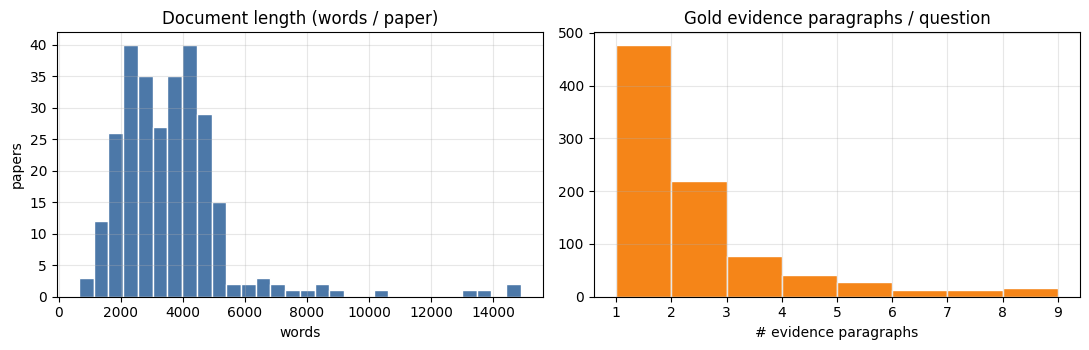

In [14]:
def n_words(t: str) -> int: return len(t.split())

word_counts = np.array([n_words(d.page_content) for d in CORPUS])
n_questions_per_paper = pd.Series([e["paper_id"] for e in EVALSET]).value_counts()

print("Words per paper:")
print(pd.Series(word_counts).describe().round(0).to_string())
print(f"\nA MiniLM/OpenAI embedding handles a few hundred words at a time, but the median paper is "
      f"~{int(np.median(word_counts))} words → it MUST be chunked.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(word_counts, bins=30, color="#4C78A8", edgecolor="white")
ax[0].set_title("Document length (words / paper)"); ax[0].set_xlabel("words"); ax[0].set_ylabel("papers")
ax[1].hist([len(e["evidence"]) for e in EVALSET], bins=range(1, 10), color="#F58518", edgecolor="white")
ax[1].set_title("Gold evidence paragraphs / question"); ax[1].set_xlabel("# evidence paragraphs")
plt.tight_layout(); plt.show()

In [15]:
# --- §3.2 · The use case, in the data's own numbers --------------------------
_w = lambda t: set(re.sub(r"[^a-z0-9 ]+", " ", t.lower()).split())

words = np.array([len(d.page_content.split()) for d in CORPUS])
tok = words * 1.3                                  # ~1.3 tokens per English word
CTX = 128_000                                      # a large modern context window

print("THE CORPUS")
print(f"  {len(CORPUS)} papers · {words.sum():,} words · ≈{tok.sum()/1000:,.0f}k tokens")
print(f"  median paper {int(np.median(words)):,} words (≈{int(np.median(tok)):,} tokens), "
      f"longest {words.max():,} words")
print(f"  → {tok.sum()/CTX:.1f}× a {CTX//1000}k context window: cannot be prompted, must be retrieved")
print(f"  → the MEDIAN paper is ≈{np.median(tok)/256:.0f}× an embedding model's 256-token input "
      f"limit: cannot be one vector, must be chunked")

print("\nTHE QUERIES  (real questions, real gold evidence — not synthetic)")
print(f"  {len(EVALSET)} answerable questions across those papers\n")
_titles = {d.metadata["paper_id"]: d.metadata.get("title", "") for d in CORPUS}
for e in EVALSET[:3]:
    print("  Q        :", e["question"])
    print("  paper    :", short(_titles.get(e["paper_id"], e["paper_id"]), 78))
    print("  answer   :", short(str(e.get("answer") or "—"), 96))
    print("  evidence :", short(e["evidence"][0], 130), "\n")

print("\nSUCCESS CRITERIA")
print(f"  1. hit@{CFG.eval_k} — is a gold-evidence chunk in the top-{CFG.eval_k}?   (can we find it at all)")
print( "  2. MRR         — is it near the top?                (is it ranked well)")
print( "  3. grounded + cited answer (§11)                    (does the LLM actually use it)")

THE CORPUS
  281 papers · 1,025,219 words · ≈1,333k tokens
  median paper 3,484 words (≈4,529 tokens), longest 14,894 words
  → 10.4× a 128k context window: cannot be prompted, must be retrieved
  → the MEDIAN paper is ≈18× an embedding model's 256-token input limit: cannot be one vector, must be chunked

THE QUERIES  (real questions, real gold evidence — not synthetic)
  892 answerable questions across those papers

  Q        : Is the LSTM baseline a sub-word model?
  paper    : Finnish Language Modeling with Deep Transformer Models
  answer   : —
  evidence : The original BERT has two training objectives: 'Masked language modelling', in which you mask input tokens randomly and then predi … 

  Q        : Which additional latent variables are used in the model?
  paper    : A Bayesian Model of Multilingual Unsupervised Semantic Role Induction
  answer   : —
  evidence : The multilingual model uses word alignments between sentences in a parallel corpus to exploit role correspondences 

## 2 · Embeddings

An embedding maps text to a vector so that **semantic similarity becomes geometric proximity**:

Two production-standard choices:

| | Sentence-Transformers (SBERT) | OpenAI |
|---|---|---|
| where it runs | **locally**, free, offline | hosted API (paid) |
| default model | `all-MiniLM-L6-v2` (384-d) | `text-embedding-3-small` (1536-d) |
| good for | most workloads, full control, privacy | top quality with zero infra |


We **L2-normalize** every vector. With unit-magnitude vectors, **inner product equals
cosine similarity**, `A⋅B=∥A∥∥B∥cos(θ)`

This lets us use one FAISS metric (inner product) for *every* index type later.

In [16]:
from sentence_transformers import SentenceTransformer

class Embedder:
    """Common interface: .embed(texts) -> float32 array (n, dim), L2-normalized if CFG.normalize."""
    name: str; dim: int
    def embed(self, texts: List[str], show_progress: bool = False) -> np.ndarray: ...
    def embed_query(self, text: str) -> np.ndarray:
        return self.embed([text])[0]

class SbertEmbedder(Embedder):
    def __init__(self, model_name: str = CFG.sbert_model):
        self.model = SentenceTransformer(model_name, device=DEVICE)
        self.name = model_name.split("/")[-1]
        self.dim = self.model.get_sentence_embedding_dimension()
    def embed(self, texts, show_progress=False):
        v = self.model.encode(texts, batch_size=CFG.embed_batch_size,
                              normalize_embeddings=CFG.normalize,
                              convert_to_numpy=True, show_progress_bar=show_progress)
        return v.astype("float32")

EMB = SbertEmbedder()       # the default embedder used throughout
print(f"Embedder: {EMB.name}  |  dim={EMB.dim}  |  device={DEVICE}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedder: all-MiniLM-L6-v2  |  dim=384  |  device=cuda


In [17]:
class OpenAIEmbedder(Embedder):
    """Drop-in OpenAI embeddings. Only usable when OPENAI_API_KEY is set."""
    def __init__(self, model_name: str = CFG.openai_model):
        from openai import OpenAI
        self.client = OpenAI()
        self.name = model_name; self.model_name = model_name
        self.dim = 1536 if "small" in model_name else 3072
    def embed(self, texts, show_progress=False):
        out = []
        for i in range(0, len(texts), 256):                 # API batch limit
            resp = self.client.embeddings.create(model=self.model_name, input=texts[i:i+256])
            out.extend([e.embedding for e in resp.data])
        v = np.asarray(out, dtype="float32")
        if CFG.normalize:                                   # match SBERT: unit norm → IP == cosine
            v /= (np.linalg.norm(v, axis=1, keepdims=True) + 1e-12)
        return v

OPENAI_EMB = OpenAIEmbedder() if HAS_OPENAI else None
print("OpenAI embedder:", "ready" if OPENAI_EMB else "skipped (no key) — using SBERT everywhere")

OpenAI embedder: skipped (no key) — using SBERT everywhere


### 2.1 · Does the geometry mean anything?

* Embed a few sentences and look at pairwise cosine similarity.
* We expect the two paraphrases of the *same* idea to score **highest**, and the *unrelated* sentence to score **lowest** with everything.

In [18]:
probe = [
    "How do I cite a source in this format?",     # 0
    "What is the required citation style?",        # 1  (paraphrase of 0)
    "The cat slept on the warm windowsill.",       # 2  (unrelated)
    "Approximate nearest-neighbour search trades a little accuracy for speed.",  # 3
]
V = EMB.embed(probe)                 # probes --> Embedding Model --> (sentence embeddings) e0, e1, e2, e3
sim = V @ V.T         # Matrix Multiplication of V and V_transpose
df = pd.DataFrame(sim, columns=[f"s{i}" for i in range(len(probe))],
                       index=[f"s{i}: {short(p,38)}" for i, p in enumerate(probe)])
print(df.round(2).to_string())
print("\ns0–s1 (paraphrases) should be the highest off-diagonal pair; s2 (the cat) lowest with the rest.")

                                                s0    s1    s2    s3
s0: How do I cite a source in this format?    1.00  0.69  0.07 -0.07
s1: What is the required citation style?      0.69  1.00 -0.02  0.02
s2: The cat slept on the warm windowsill.     0.07 -0.02  1.00 -0.04
s3: Approximate nearest-neighbour search t … -0.07  0.02 -0.04  1.00

s0–s1 (paraphrases) should be the highest off-diagonal pair; s2 (the cat) lowest with the rest.


## 3 · Chunking strategies

A chunk is the atomic unit that gets embedded and retrieved.

Each chunk should hold one self-contained, **retrievable idea** - small enough to be precise, large enough to stand alone.​

- **too small** → each chunk lacks context; the answer is split across several chunks and none is individually convincing;
- **too large** → one vector must summarize many ideas, so the embedding is "blurry" and irrelevant
  text dilutes the match; you also waste the LLM's context window.

We implement the three strategies learnt in the course, each as a simple
`text -> list[str]` function so they are interchangeable.

| strategy | splits on | keeps meaning together? | cost |
|---|---|---|---|
| **fixed-size** | character count | no (cuts mid-sentence) | trivial |
| **sliding window** | sentences, with overlap | yes, with overlap storage | cheap |
| **semantic** | embedding-similarity dips | yes (topic shifts) | needs embeddings |

In [19]:
from langchain_text_splitters import (CharacterTextSplitter, RecursiveCharacterTextSplitter,
                                       TokenTextSplitter)

# ---- 1) fixed-size (hard character windows; CharacterTextSplitter with an empty separator) ----
def fixed_splitter(size: int, overlap: int) -> Callable[[str], List[str]]:
    sp = CharacterTextSplitter(separator="", chunk_size=size, chunk_overlap=overlap)    # treats the text as a continuous character stream.
    """
    Chunk 1:    [------------------------------------100 chars------------------------------------]

    Chunk 2:                                                            [------------------------------------100 chars------------------------------------]
                                                                        ↑
                                                                        20 chars
                                                                        overlap
    """
    return lambda t: sp.split_text(t)         # splitter = fixed_splitter(500, 50);  chunks = splitter(document)


# ---- 2) sliding window over SENTENCES (overlapping windows → redundancy helps recall) ----
def sliding_splitter(window_sents: int = 5, stride_sents: int = 3) -> Callable[[str], List[str]]:         # W1 → sent 1–5, W2 → sent 4–8, W3 → sent 7–11;  overlap = Win-str
    def split(t: str) -> List[str]:
        sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", t) if s.strip()]     # text --> sent ; punctuations "." "!" "?" ; removes unnecessary whitespaces
        if not sents: return []
        out, i = [], 0
        while i < len(sents):
            out.append(" ".join(sents[i:i + window_sents]))    # sent[0:5] --> join each to form one sentence
            if i + window_sents >= len(sents): break      # if current window reached EOS.
            i += stride_sents             # sent[3:8]
        return out
    return split

print("Fixed / sliding splitters ready.")

Fixed / sliding splitters ready.


In [20]:
# ---- 3) semantic chunking: split where where the meaning/topic changes between consecutive sentences. ----
from langchain_huggingface import HuggingFaceEmbeddings     # Langchain wrapper around huggingface Embedding Models
from langchain_experimental.text_splitter import SemanticChunker    # LangChain's semantic text-splitting algorithm.

lc_embeddings = HuggingFaceEmbeddings(
    model_name=CFG.sbert_model,
    model_kwargs={"device": DEVICE},
    encode_kwargs={"normalize_embeddings": True})

def semantic_splitter(threshold_type: str = "percentile", amount: int = 90) -> Callable[[str], List[str]]:
    chunker = SemanticChunker(lc_embeddings,
                              breakpoint_threshold_type=threshold_type,
                              breakpoint_threshold_amount=amount)           # distribution of sentence-to-sentence similarity; semantic-distance > 90 percentile
    return lambda t: chunker.split_text(t)

print("Semantic splitter ready (embeds sentences, so it is the slowest of the three).")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Semantic splitter ready (embeds sentences, so it is the slowest of the three).


### 3.1 · See each strategy on one real paragraph

Same input, three strategies.

Notice how fixed-size slices mid-word, sliding-window chunks overlap on purpose, and semantic chunks vary in length because they
follow topic shifts rather than a fixed budget.

In [21]:
sample_text = CORPUS[0].page_content[:1400]
print("INPUT (first 1400 chars of paper 0):\n" + textwrap.fill(sample_text[:400], 100) + " …\n")

demos = {
    "fixed (300/60)":      fixed_splitter(300, 60),
    "sliding (5 sent/3)":  sliding_splitter(5, 3),
    "semantic (pct 90)":   semantic_splitter("percentile", 90),
}
for name, fn in demos.items():
    chunks = fn(sample_text)
    avg = int(np.mean([len(c) for c in chunks])) if chunks else 0
    print(f"\n● {name:18s} → {len(chunks):2d} chunks, avg {avg} chars")
    print("   first chunk:", short(chunks[0].replace(chr(10), ' '), 130) if chunks else "—")

INPUT (first 1400 chars of paper 0):
Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation  Abstract
Transfer learning between different language pairs has shown its effectiveness for Neural Machine
Translation (NMT) in low-resource scenario. However, existing transfer methods involving a common
target language are far from success in the extreme scenario of zero-shot translation, due to the
language spac …


● fixed (300/60)     →  6 chunks, avg 283 chars
   first chunk: Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation  Abstract Transfer learning between different l …

● sliding (5 sent/3) →  2 chunks, avg 845 chars
   first chunk: Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation  Abstract Transfer learning between different l …

● semantic (pct 90)  →  2 chunks, avg 699 chars
   first chunk: Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation  Abstract Trans

### 3.2 · Turn a strategy into a corpus of chunk `Document`s

Downstream we always need `Document`s carrying enough metadata to (a) trace a chunk back to its
paper and (b) score retrieval. This helper applies any `text -> list[str]` splitter to the whole
corpus and stamps that metadata on every chunk.

In [22]:
def chunk_corpus(splitter: Callable[[str], List[str]], strategy: str,
                 docs: List[Document] = None) -> List[Document]:
    docs = docs if docs is not None else CORPUS
    chunks: List[Document] = []
    for d in docs:
        for j, piece in enumerate(splitter(d.page_content)):
            piece = piece.strip()
            if len(piece) < 20:               # drop slivers
                continue
            chunks.append(Document(
                page_content=piece,
                metadata={"paper_id": d.metadata["paper_id"], "title": d.metadata["title"],
                          "strategy": strategy, "chunk_id": f'{d.metadata["paper_id"]}::{j}'}))
    return chunks

_demo_chunks = chunk_corpus(semantic_splitter("percentile", 90), "semantic")
print(f"Semantic chunking of {len(CORPUS)} papers → {len(_demo_chunks)} chunks")
print("example chunk metadata:", _demo_chunks[0].metadata)

Semantic chunking of 281 papers → 4977 chunks
example chunk metadata: {'paper_id': '1912.01214', 'title': 'Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation', 'strategy': 'semantic', 'chunk_id': '1912.01214::0'}


## 4 · Chunking experiments

We now want to build a retrieval system and measure whether it successfully retrieves the piece of text that actually contains the answer.

For each strategy we: chunk the corpus → embed every
chunk → build an **exact** index → run all evaluation questions → and check whether a **gold
evidence** passage shows up in the top-k.

A retrieved chunk counts as **relevant** to a question when it comes from the right paper *and*
shares a substantial fraction of its words with one of that question's gold evidence paragraphs
(overlap coefficient ≥ 0.5). This tolerates the fact that chunk boundaries rarely line up exactly
with evidence boundaries. Two metrics:

- **Hit@k** — fraction of questions with at least one relevant chunk in the top-k (can the system
  *find* the answer at all?).
- **MRR** — mean reciprocal rank of the first relevant chunk (does it find it *near the top*?).

In [23]:
import faiss      # store embeddings and perform vector similarity search.    Query embedding --> FAISS --> Top-k similar document chunks

_word_re = re.compile(r"[^a-z0-9 ]+")     # remove special characters

def toks(t: str) -> set:    # custom tokenization
    return set(_word_re.sub(" ", t.lower()).split())      # lowercase, remove punctuation, split into words --> set

def overlap_coef(a: set, b: set) -> float:      # measures how much the smaller set overlaps with the larger set.
    if not a or not b: return 0.0
    return len(a & b) / min(len(a), len(b))     # min: len(gold) may be < len(chunk)

def is_relevant(chunk: Document, q: dict, thr: float = 0.5) -> bool:              # Is this retrieved document chunk relevant to the query?
    """Relevant = same paper AND high word-overlap with any gold evidence paragraph."""
    if chunk.metadata.get("paper_id") != q["paper_id"]:
        return False
    ct = toks(chunk.page_content)     # Tokenize the retrieved chunk
    return any(overlap_coef(toks(ev), ct) >= thr for ev in q["evidence"])     # query['evidence'] contains gold evidence paragraphs.

def score_retrieval(retrieved_per_q: List[List[Document]], queries: List[dict], k: int) -> dict:
    hits, rrs = [], []
    for retrieved, q in zip(retrieved_per_q, queries):      # each query is evaluated against its own retrieved chunks.
        flags = [is_relevant(c, q) for c in retrieved[:k]]      # check relevance of top-k chunks : [A,B,C] --> Flags [False, True, False]
        hits.append(1.0 if any(flags) else 0.0)                          # 1 if at least one of the top-k chunks was relevant, else 0.
        rr = next((1.0 / r for r, f in enumerate(flags, 1) if f), 0.0)      # RR = 1 / rank of first relevant result
        rrs.append(rr)
    return {"hit@k": float(np.mean(hits)), "mrr": float(np.mean(rrs))}    # Mean across all queries

In [24]:
def embed_and_index(chunks: List[Document], embedder: Embedder):      # converts document chunks into vectors and stores them in a FAISS index.
    """Embed chunk texts and build an exact (Flat inner-product) index."""
    t0 = time.perf_counter()
    vecs = embedder.embed([c.page_content for c in chunks], show_progress=False)
    embed_s = time.perf_counter() - t0
    index = faiss.IndexFlatIP(embedder.dim)
    index.add(vecs)
    return index, vecs, embed_s

def retrieve(index, embedder, queries: List[dict], chunks: List[Document], k: int):
    qv = embedder.embed([q["question"] for q in queries])
    _, I = index.search(qv, k)
    return [[chunks[i] for i in row] for row in I]

In [25]:
# The configurations to compare. (Semantic chunking embeds sentences, so it is the slow one —
# on CPU this whole cell can take a few minutes; on a T4 it is quick.)
chunking_configs = {
    "fixed-400/80":     fixed_splitter(400, 80),
    "fixed-800/160":    fixed_splitter(800, 160),
    "sliding-5/3":      sliding_splitter(5, 3),
    "semantic-pct90":   semantic_splitter("percentile", 90),
}

results, store = [], {}
for name, splitter in chunking_configs.items():
    chunks = chunk_corpus(splitter, name)
    index, vecs, embed_s = embed_and_index(chunks, EMB)
    retrieved = retrieve(index, EMB, EVALSET, chunks, CFG.eval_k)
    sc = score_retrieval(retrieved, EVALSET, CFG.eval_k)
    avg_len = float(np.mean([len(c.page_content) for c in chunks]))
    results.append({"strategy": name, "chunks": len(chunks), "avg_chars": round(avg_len),
                    f"hit@{CFG.eval_k}": round(sc["hit@k"], 3), "MRR": round(sc["mrr"], 3),
                    "embed_s": round(embed_s, 1)})
    store[name] = {"chunks": chunks, "vecs": vecs}
    print(f"✓ {name:18s} {len(chunks):5d} chunks  hit@{CFG.eval_k}={sc['hit@k']:.3f}  MRR={sc['mrr']:.3f}")

res_df = pd.DataFrame(results).sort_values(f"hit@{CFG.eval_k}", ascending=False).reset_index(drop=True)
res_df

✓ fixed-400/80       21170 chunks  hit@10=0.254  MRR=0.138
✓ fixed-800/160      10618 chunks  hit@10=0.257  MRR=0.137
✓ sliding-5/3        15529 chunks  hit@10=0.258  MRR=0.142
✓ semantic-pct90      4977 chunks  hit@10=0.271  MRR=0.138


,strategy,chunks,avg_chars,hit@10,MRR,embed_s
0,semantic-pct90,4977,1353,0.271,0.138,13.8
1,sliding-5/3,15529,714,0.258,0.142,39.2
2,fixed-800/160,10618,791,0.257,0.137,30.4
3,fixed-400/80,21170,398,0.254,0.138,33.7


semantic chunking finds the correct information in the top-10 slightly more often, sliding-window chunking tends to put the relevant chunk slightly higher in the ranking.

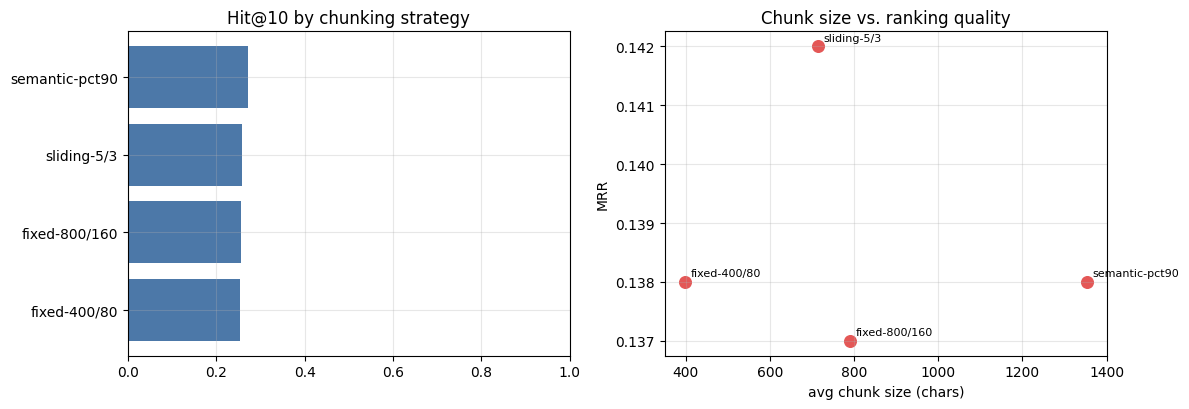

In [26]:
# Visualize the trade-offs.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
order = res_df["strategy"]
ax[0].barh(order, res_df[f"hit@{CFG.eval_k}"], color="#4C78A8")
ax[0].set_title(f"Hit@{CFG.eval_k} by chunking strategy"); ax[0].invert_yaxis(); ax[0].set_xlim(0, 1)
ax[1].scatter(res_df["avg_chars"], res_df["MRR"], s=70, color="#E45756")
for _, r in res_df.iterrows():
    ax[1].annotate(r["strategy"], (r["avg_chars"], r["MRR"]), fontsize=8,
                   xytext=(4, 4), textcoords="offset points")
ax[1].set_xlabel("avg chunk size (chars)"); ax[1].set_ylabel("MRR"); ax[1].set_title("Chunk size vs. ranking quality")
plt.tight_layout(); plt.show()

## 5 · The exact baseline

Before approximating anything, build the **exact** search that every approximate method will be
measured against. With our unit-normalized vectors,

`IndexFlatIP` computes the inner product =
**cosine similarity** between the query and every chunk, then returns the true top-k. It is
**100% accurate by definition** — and perfectly fast at our scale. Its only problem is that it
scans *every* vector, so cost grows linearly with corpus size; that is what §8 fixes.

We wrap it in a small `SemanticSearcher` so the query path (embed → search → attach metadata) is
one call. The same class will happily wrap an approximate index later — the interface never changes.

In [27]:
class SemanticSearcher:
    """Embed a query, search a FAISS index, return (chunk, score) pairs with metadata."""
    def __init__(self, embedder: Embedder, chunks: List[Document], index: "faiss.Index"):
        self.embedder, self.chunks, self.index = embedder, chunks, index
    @classmethod
    def exact(cls, embedder, chunks, vecs):
        index = faiss.IndexFlatIP(embedder.dim); index.add(vecs)
        return cls(embedder, chunks, index)
    def search(self, query: str, k: int = CFG.top_k) -> List[Tuple[Document, float]]:
        qv = self.embedder.embed_query(query).reshape(1, -1)
        scores, ids = self.index.search(qv, k)
        return [(self.chunks[i], float(s)) for s, i in zip(scores[0], ids[0]) if i != -1]

searcher = SemanticSearcher.exact(EMB, CHUNKS, CHUNK_VECS)
print("Exact searcher ready over", len(CHUNKS), "chunks.")

NameError: name 'CHUNKS' is not defined

In [ ]:
def show_results(query: str, hits: List[Tuple[Document, float]]):
    print("Q:", query, "\n" + "-" * 96)
    for rank, (doc, score) in enumerate(hits, 1):
        print(f"[{rank}] cos={score:.3f}  ·  {short(doc.metadata.get('title','') or doc.metadata['paper_id'], 60)}")
        print("     ", short(doc.page_content.replace(chr(10), ' '), 150))

demo_q = EVALSET[0]["question"]
show_results(demo_q, searcher.search(demo_q, k=CFG.top_k))
print("\n(The top hit should come from the same paper as the question and read on-topic.)")